# BirdCLEF2026 - Exploratory Data Analysis

This notebook explores the training data, taxonomy, and soundscape labels to understand:

1. **Data structure** - What we're working with
2. **Class distribution** - How balanced the problem is
3. **Taxonomy** - What types of species we're classifying
4. **Geographic distribution** - Where recordings come from
5. **Data quality** - Reliability of labels
6. **Multi-label nature** - Background species in recordings
7. **Soundscape labels** - Field recording data
8. **Submission format** - How to format predictions

Understanding these aspects is critical for making informed modeling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path("../input")
TRAIN_AUDIO_DIR = DATA_DIR / "train_audio"
TRAIN_SOUNDSCAPES_DIR = DATA_DIR / "train_soundscapes"
TEST_SOUNDSCAPES_DIR = DATA_DIR / "test_soundscapes"

# Load data
train_df = pd.read_csv(DATA_DIR / "train.csv")
taxonomy_df = pd.read_csv(DATA_DIR / "taxonomy.csv")
train_labels_df = pd.read_csv(DATA_DIR / "train_soundscapes_labels.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("Data loaded successfully!")
print(f"\nFiles available:")
print(f"  - train.csv: {len(train_df):,} rows")
print(f"  - taxonomy.csv: {len(taxonomy_df)} rows")
print(f"  - train_soundscapes_labels.csv: {len(train_labels_df):,} rows")
print(f"  - sample_submission.csv: {len(sample_submission):,} rows")

Data loaded successfully!

Files available:
  - train.csv: 35,549 rows
  - taxonomy.csv: 234 rows
  - train_soundscapes_labels.csv: 1,478 rows
  - sample_submission.csv: 3 rows


## 1. Dataset Overview

**Why this matters:**

Understanding the data structure helps us design appropriate preprocessing and modeling strategies. The training data comes from two sources with different characteristics:

- **Xeno-canto (XC)**: Expert-contributed recordings with quality ratings
- **iNaturalist**: Citizen science recordings, may have different quality profiles

The test data comes from **field recordings** in the Pantanal - this creates a domain shift challenge!

In [2]:
print("="*50)
print("TRAINING DATA OVERVIEW")
print("="*50)
print(f"\nTotal training audio files: {len(train_df):,}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nData types:\n{train_df.dtypes}")

TRAINING DATA OVERVIEW

Total training audio files: 35,549

Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

Data types:
primary_label           str
secondary_labels        str
type                    str
latitude            float64
longitude           float64
scientific_name         str
common_name             str
class_name              str
inat_taxon_id         int64
author                  str
license                 str
rating              float64
url                     str
filename                str
collection              str
dtype: object


In [3]:
train_df.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


## 2. Species Distribution

**Why this matters:**

This is a **multi-label classification** problem with significant class imbalance:

1. **Some species have hundreds of samples** - These will be easier to learn
2. **Many species have very few samples** - These need data augmentation or transfer learning
3. **The median is much lower than the mean** - Indicates long-tail distribution

**Implications for modeling:**
- Use **weighted loss** or **focal loss** to handle imbalance
- **Data augmentation** is critical for rare species
- Consider **transfer learning** from similar species
- May need to **threshold predictions** differently per class

In [4]:
# Count samples per species
species_counts = train_df['primary_label'].value_counts()
print(f"Number of unique species in train.csv: {len(species_counts)}")
print(f"\nSpecies with most samples:")
print(species_counts.head(20))
print(f"\nSpecies with fewest samples:")
print(species_counts.tail(10))

Number of unique species in train.csv: 206

Species with most samples:
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
bncfly     492
bobfly1    492
bbwduc     491
trsowl     491
whtdov     491
sobtyr1    490
roahaw     489
strcuc1    485
trokin     483
grekis     482
Name: count, dtype: int64

Species with fewest samples:
primary_label
64898      3
74580      3
sptnig1    3
209233     2
24321      2
70711      2
116570     1
23150      1
23724      1
516975     1
Name: count, dtype: int64


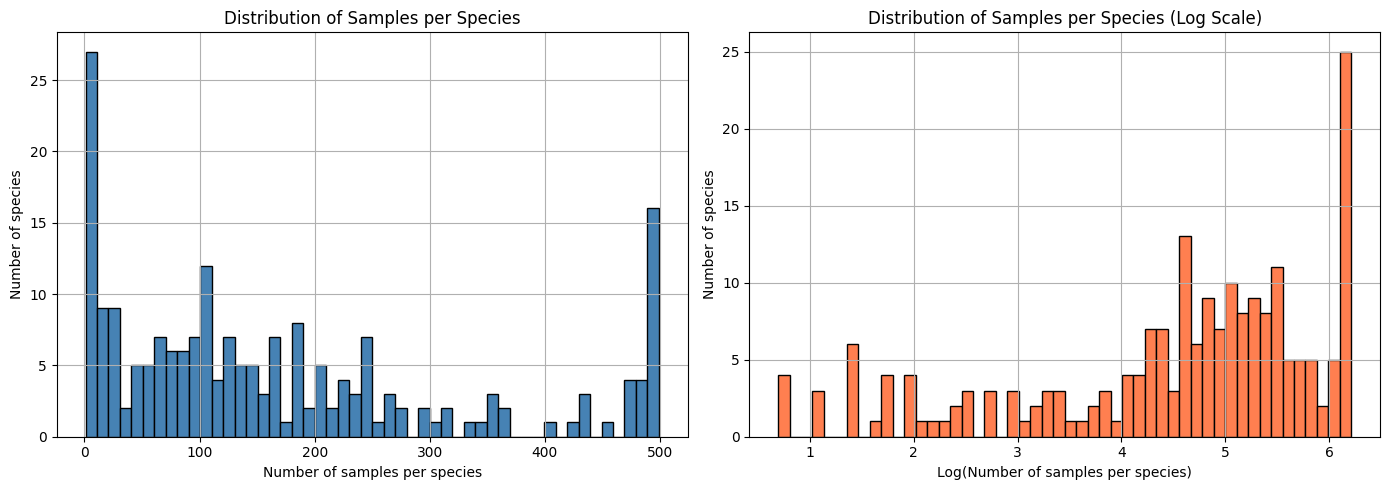


Statistics:
  Mean samples per species: 172.6
  Median samples per species: 125.0
  Min samples per species: 1
  Max samples per species: 499

⚠️  Species with <10 samples: 25 (12.1%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of samples per species
ax1 = axes[0]
species_counts.hist(bins=50, ax=ax1, edgecolor='black', color='steelblue')
ax1.set_xlabel('Number of samples per species')
ax1.set_ylabel('Number of species')
ax1.set_title('Distribution of Samples per Species')

# Log-scale distribution
ax2 = axes[1]
np.log1p(species_counts).hist(bins=50, ax=ax2, edgecolor='black', color='coral')
ax2.set_xlabel('Log(Number of samples per species)')
ax2.set_ylabel('Number of species')
ax2.set_title('Distribution of Samples per Species (Log Scale)')

plt.tight_layout()
plt.savefig('species_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nStatistics:")
print(f"  Mean samples per species: {species_counts.mean():.1f}")
print(f"  Median samples per species: {species_counts.median():.1f}")
print(f"  Min samples per species: {species_counts.min()}")
print(f"  Max samples per species: {species_counts.max()}")
print(f"\n⚠️  Species with <10 samples: {(species_counts < 10).sum()} ({(species_counts < 10).sum() / len(species_counts) * 100:.1f}%)")

## 3. Class Distribution (Taxonomy)

**Why this matters:**

The competition includes **multiple taxonomic classes**:

- **Aves** (birds) - Most species, primary focus
- **Amphibia** (frogs) - Important in Pantanal wetlands
- **Insecta** (insects) - Includes sonotypes (unidentified species)
- **Mammalia** (mammals) - Including Jaguar!
- **Reptilia** (reptiles) - Including Caiman

**Key insight**: Different classes may have different acoustic characteristics:
- Birds: Higher frequencies, distinct songs/calls
- Frogs: Lower frequencies, repetitive calls
- Insects: High frequencies, continuous sounds
- Mammals: Wide frequency range, diverse vocalizations

This diversity suggests using **class-specific preprocessing** or **class-specific models** could help.

In [6]:
print("="*50)
print("TAXONOMY OVERVIEW")
print("="*50)
print(f"\nTotal classes (species): {len(taxonomy_df)}")
print(f"\nClass distribution by taxon:")
class_counts = taxonomy_df['class_name'].value_counts()
print(class_counts)

TAXONOMY OVERVIEW

Total classes (species): 234

Class distribution by taxon:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


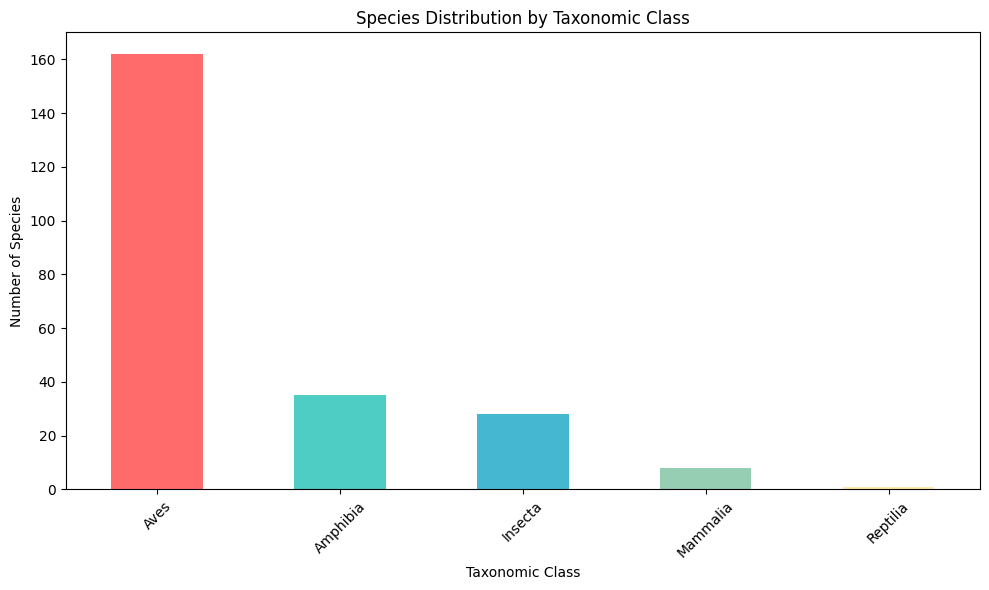


Example species from each class:

Aves:
  - ashgre1: Ashy-headed Greenlet
  - astcra1: Ash-throated Crake

Amphibia:
  - 1176823: Wrestler Frog
  - 1491113: Guaraní leaf-litter frog

Insecta:
  - 1161364: Guyalna cuta
  - 244024: Giant Cicada

Mammalia:
  - 209233: Feral Horse
  - 41970: Jaguar

Reptilia:
  - 116570: Southern Spectacled Caiman


In [7]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Aves': '#FF6B6B', 'Amphibia': '#4ECDC4', 'Insecta': '#45B7D1', 'Mammalia': '#96CEB4', 'Reptilia': '#FFEAA7'}
bar_colors = [colors.get(c, '#888888') for c in class_counts.index]
class_counts.plot(kind='bar', ax=ax, color=bar_colors)
ax.set_xlabel('Taxonomic Class')
ax.set_ylabel('Number of Species')
ax.set_title('Species Distribution by Taxonomic Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Show examples from each class
print("\nExample species from each class:")
for class_name in class_counts.index:
    examples = taxonomy_df[taxonomy_df['class_name'] == class_name].head(2)[['primary_label', 'common_name']]
    print(f"\n{class_name}:")
    for _, row in examples.iterrows():
        print(f"  - {row['primary_label']}: {row['common_name']}")

## 4. Geographic Distribution

**Why this matters:**

Bird calls can have **local dialects** - same species may have different vocalizations in different regions:

1. **Training data spans South America** - Many recordings from outside Pantanal
2. **Test data is Pantanal-specific** - Field recordings from the wetland

This creates a **geographic domain shift** that could hurt model performance.

**Mitigation strategies:**
- Prioritize recordings closer to Pantanal region (latitude ~-18, longitude ~-57)
- Use data augmentation to simulate geographic variation
- Train on train_soundscapes which are from the same region as test

In [8]:
# Check geographic coverage
print("Geographic distribution of recordings:")
print(f"  Latitude range: {train_df['latitude'].min():.2f} to {train_df['latitude'].max():.2f}")
print(f"  Longitude range: {train_df['longitude'].min():.2f} to {train_df['longitude'].max():.2f}")
print(f"  Missing coordinates: {train_df['latitude'].isna().sum()} ({train_df['latitude'].isna().sum()/len(train_df)*100:.1f}%)")

# Pantanal approximate center
PANTANAL_LAT = -18
PANTANAL_LON = -57

# Calculate distance from Pantanal
train_df['lat_diff'] = abs(train_df['latitude'] - PANTANAL_LAT)
train_df['lon_diff'] = abs(train_df['longitude'] - PANTANAL_LON)
train_df['geo_diff'] = train_df['lat_diff'] + train_df['lon_diff']

print(f"\n📍 Distance from Pantanal (approx):")
print(f"  Closest recordings: {train_df['geo_diff'].min():.1f}")
print(f"  Mean distance: {train_df['geo_diff'].mean():.1f}")
print(f"  Within 5 degrees: {(train_df['geo_diff'] < 5).sum()} ({(train_df['geo_diff'] < 5).sum()/len(train_df)*100:.1f}%)")

Geographic distribution of recordings:
  Latitude range: -54.86 to 69.58
  Longitude range: -159.66 to 175.32
  Missing coordinates: 0 (0.0%)

📍 Distance from Pantanal (approx):
  Closest recordings: 0.5
  Mean distance: 32.4
  Within 5 degrees: 1420 (4.0%)


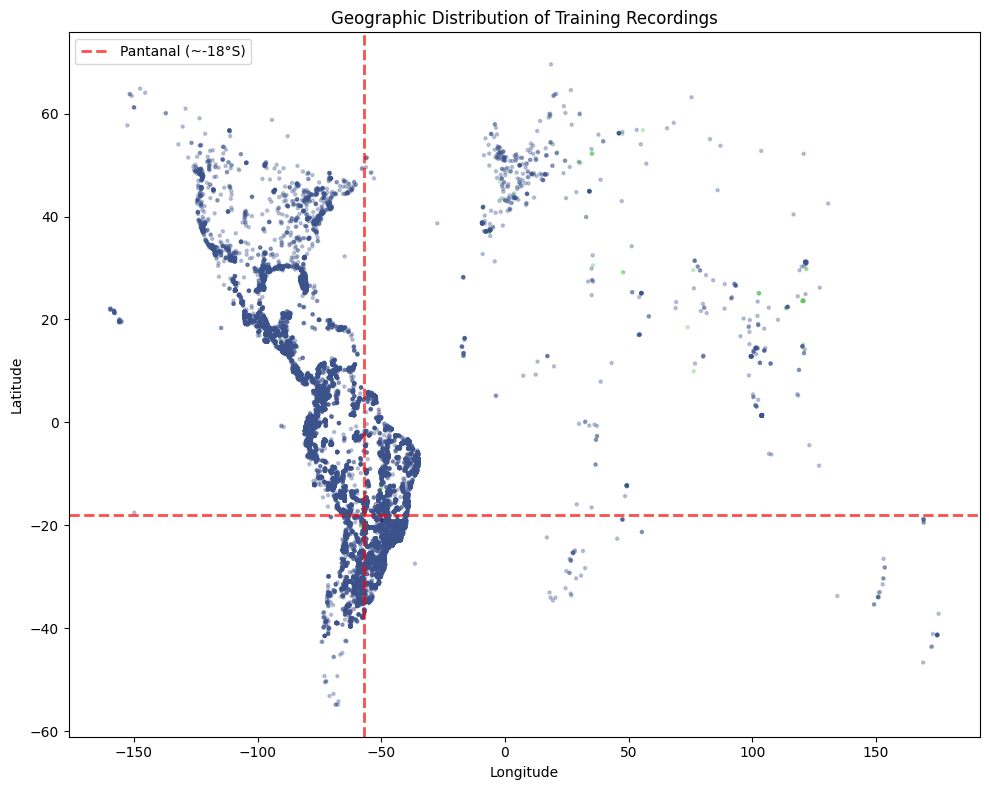

In [9]:
# Plot geographic distribution
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(train_df['longitude'], train_df['latitude'], 
                     c=train_df['class_name'].astype('category').cat.codes,
                     alpha=0.3, s=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Training Recordings')

# Add Pantanal region marker
ax.axhline(y=PANTANAL_LAT, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Pantanal (~{PANTANAL_LAT}°S)')
ax.axvline(x=PANTANAL_LON, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('geographic_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Data Quality Analysis

**Why this matters:**

Data quality varies significantly:

1. **Rating distribution**: 0 = no rating available, 1-5 = quality (lower if background species present)
2. **Collection source**: XC vs iNaturalist have different quality standards
**Implications:**
- Use **rating as sample weight** - higher quality = more reliable label
- Consider **filtering low-quality** samples for validation
- XC recordings tend to be more curated


In [10]:
# Rating distribution
print("Rating distribution:")
print(train_df['rating'].value_counts().sort_index())

# Collection source
print("\nCollection source:")
print(train_df['collection'].value_counts())

Rating distribution:
rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64

Collection source:
collection
XC      23043
iNat    12506
Name: count, dtype: int64


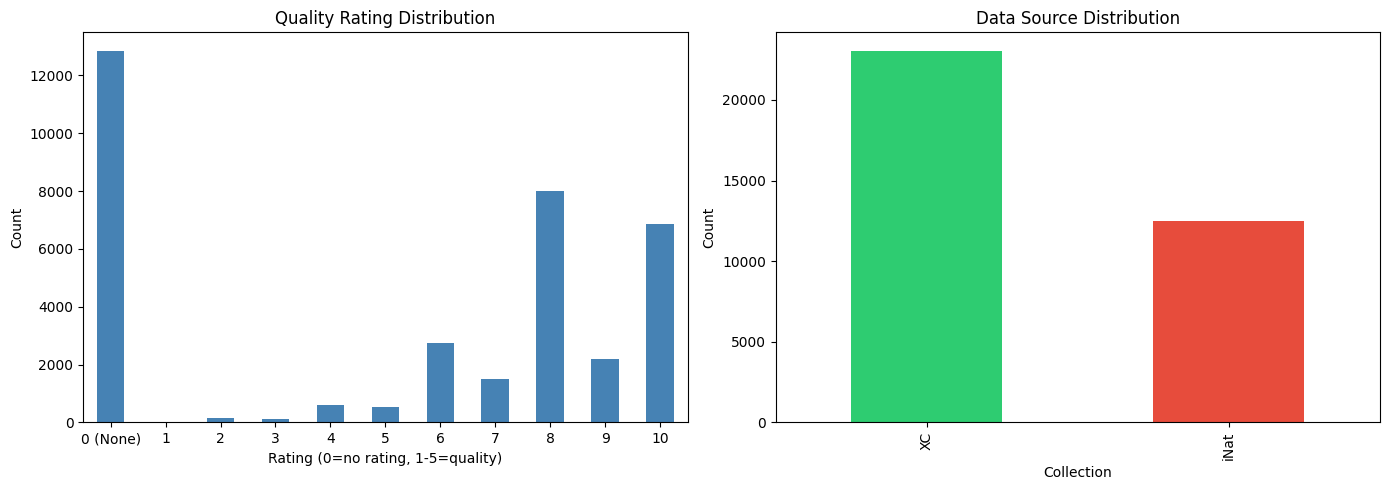


📊 Quality Insights:
  Unrated recordings: 12849 (36.1%)
  High quality (4+): 17048 (48.0%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
ax1 = axes[0]
train_df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_xlabel('Rating (0=no rating, 1-5=quality)')
ax1.set_ylabel('Count')
ax1.set_title('Quality Rating Distribution')
ax1.set_xticklabels(['0 (None)', '1', '2', '3', '4', '5', '6', '7', '8', '9','10'], rotation=0)

# Collection source
ax2 = axes[1]
train_df['collection'].value_counts().plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Collection')
ax2.set_ylabel('Count')
ax2.set_title('Data Source Distribution')

plt.tight_layout()
plt.savefig('quality_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Quality Insights:")
print(f"  Unrated recordings: {(train_df['rating'] == 0).sum()} ({(train_df['rating'] == 0).sum()/len(train_df)*100:.1f}%)")
print(f"  High quality (4+): {(train_df['rating'] >= 4).sum()} ({(train_df['rating'] >= 4).sum()/len(train_df)*100:.1f}%)")

## 6. Secondary Labels Analysis

**Why this matters:**

Many recordings contain **multiple species** - the primary label is the main species, but secondary labels indicate other species present:

1. **~26% of recordings have secondary labels** - This is valuable multi-label information
2. **Can use these for semi-supervised learning** - Train on both primary and secondary
3. **Important for field recordings** - Test data likely has overlapping species

**Implications:**
- Can create **additional training samples** from secondary labels
- Model should predict **all species present**, not just primary
- Use **multi-label loss** (BCE, not softmax)

In [12]:
# Analyze secondary labels (background species)
def count_secondary_labels(x):
    if pd.isna(x) or x == '[]':
        return 0
    try:
        return len(eval(x))
    except:
        return 0

train_df['num_secondary'] = train_df['secondary_labels'].apply(count_secondary_labels)

print("Secondary labels (background species) statistics:")
print(f"  Recordings with secondary labels: {(train_df['num_secondary'] > 0).sum()} ({(train_df['num_secondary'] > 0).sum()/len(train_df)*100:.1f}%)")
print(f"  Mean secondary labels per recording: {train_df['num_secondary'].mean():.2f}")
print(f"  Max secondary labels: {train_df['num_secondary'].max()}")

# Top secondary species
secondary_species = []
for labels in train_df[train_df['num_secondary'] > 0]['secondary_labels']:
    try:
        species_list = eval(labels)
        secondary_species.extend(species_list)
    except:
        pass

print(f"\nMost common secondary (background) species:")
print(pd.Series(secondary_species).value_counts().head(10))

Secondary labels (background species) statistics:
  Recordings with secondary labels: 4372 (12.3%)
  Mean secondary labels per recording: 0.21
  Max secondary labels: 15

Most common secondary (background) species:
grekis     624
whtdov     468
undtin1    315
yecpar     226
rufhor2    225
saffin     183
picpig2    172
trokin     171
soulap1    154
grasal3    151
Name: count, dtype: int64


## 7. Train Soundscapes Labels Analysis

**Why this matters:**

The train_soundscapes provide **critical domain-specific training data**:

1. **From same region as test** - Field recordings from Pantanal
2. **Segment-level labels** - 5-second segments with species annotations
3. **Multi-label** - Multiple species can be present per segment
4. **Some species only appear here** - Important for generalization

**Key insight**: The train_soundscapes are from the **same recording locations** as test data!
- This domain match is extremely valuable
- Should prioritize this data for training
- Can use as validation set (similar distribution to test)

In [13]:
print("="*50)
print("TRAIN SOUNDSCAPES LABELS")
print("="*50)
print(f"\nTotal labeled segments: {len(train_labels_df):,}")
print(f"\nUnique soundscape files: {train_labels_df['filename'].nunique()}")
train_labels_df.head(10)

TRAIN SOUNDSCAPES LABELS

Total labeled segments: 1,478

Unique soundscape files: 66


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
5,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:25,00:00:30,22961;23158;24321;517063;65380
6,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:30,00:00:35,22961;23158;24321;517063;65380
7,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:35,00:00:40,22961;23158;24321;517063;65380
8,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:40,00:00:45,22961;23158;24321;65380
9,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:45,00:00:50,22961;23158;24321;517063;65380


In [14]:
# Analyze species in soundscapes
all_labels = []
for labels in train_labels_df['primary_label']:
    all_labels.extend(labels.split(';'))

soundscape_species = pd.Series(all_labels).value_counts()
print(f"Unique species in train_soundscapes: {len(soundscape_species)}")
print(f"\nMost common species in soundscapes:")
print(soundscape_species.head(20))

Unique species in train_soundscapes: 75

Most common species in soundscapes:
65380         666
517063        626
22973         426
555146        420
23158         350
24279         346
24321         344
22967         310
66971         298
47158son25    168
1491113       158
chacha1       130
whtdov        126
47158son07     96
47158son17     86
undtin1        86
compau         76
litnig1        74
22961          72
47158son11     72
Name: count, dtype: int64


In [15]:
# Compare species in train_audio vs train_soundscapes
train_audio_species = set(train_df['primary_label'].unique())
soundscape_species_set = set(soundscape_species.index)

print("Species overlap analysis:")
print(f"  Species in train_audio: {len(train_audio_species)}")
print(f"  Species in train_soundscapes: {len(soundscape_species_set)}")
print(f"  Overlap: {len(train_audio_species & soundscape_species_set)}")
print(f"  Only in soundscapes: {len(soundscape_species_set - train_audio_species)}")

# Species only in soundscapes
only_in_soundscapes = soundscape_species_set - train_audio_species
if only_in_soundscapes:
    print(f"\n⚠️  CRITICAL: Species only in train_soundscapes (must learn from this data!):")
    for sp in only_in_soundscapes:
        sp_info = taxonomy_df[taxonomy_df['primary_label'] == sp]
        if len(sp_info) > 0:
            print(f"  - {sp}: {sp_info['common_name'].values[0]} ({sp_info['class_name'].values[0]})")
        else:
            print(f"  - {sp}")

Species overlap analysis:
  Species in train_audio: 206
  Species in train_soundscapes: 75
  Overlap: 47
  Only in soundscapes: 28

⚠️  CRITICAL: Species only in train_soundscapes (must learn from this data!):
  - 47158son19: Insect sonotype19 (Insecta)
  - 47158son22: Insect sonotype22 (Insecta)
  - 47158son18: Insect sonotype18 (Insecta)
  - 47158son02: Insect sonotype02 (Insecta)
  - 47158son21: Insect sonotype21 (Insecta)
  - 47158son14: Insect sonotype14 (Insecta)
  - 47158son11: Insect sonotype11 (Insecta)
  - 517063: Southern Orange-legged Leaf Frog (Amphibia)
  - 47158son25: Insect sonotype25 (Insecta)
  - 47158son10: Insect sonotype10 (Insecta)
  - 47158son16: Insect sonotype16 (Insecta)
  - 47158son20: Insect sonotype20 (Insecta)
  - 47158son04: Insect sonotype04 (Insecta)
  - 1491113: Guaraní leaf-litter frog (Amphibia)
  - 47158son09: Insect sonotype09 (Insecta)
  - 25073: Chiasmocleis mehelyi (Amphibia)
  - 47158son03: Insect sonotype03 (Insecta)
  - 47158son07: Insect son

## 8. Submission Format

**Why this matters:**

Understanding submission format is crucial:

1. **Row ID format**: `{filename}_{end_time}`
2. **12 segments per file**: 5, 10, 15, ..., 60 seconds
3. **234 species columns**: Probability for each species
4. **Test files**: ~600 files (will be populated on Kaggle)

**Prediction strategy:**
- Process each 1-minute file in 12 overlapping or non-overlapping 5-second segments
- For each segment, predict probability of each species being present
- Some species may have very low prior probability


In [16]:
print("="*50)
print("SUBMISSION FORMAT")
print("="*50)
print(f"\nSubmission shape: {sample_submission.shape}")
print(f"Number of rows to predict: {len(sample_submission)}")
print(f"Number of species columns: {sample_submission.shape[1] - 1}")
print(f"\nFirst few rows:")
print(sample_submission.head())

SUBMISSION FORMAT

Submission shape: (3, 235)
Number of rows to predict: 3
Number of species columns: 234

First few rows:
                                    row_id   1161364    116570   1176823  \
0   BC2026_Test_0001_S05_20250227_010002_5  0.004274  0.004274  0.004274   
1  BC2026_Test_0001_S05_20250227_010002_10  0.004274  0.004274  0.004274   
2  BC2026_Test_0001_S05_20250227_010002_15  0.004274  0.004274  0.004274   

    1491113   1595929    209233     22930     22956     22961  ...   whnjay1  \
0  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  ...  0.004274   
1  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  ...  0.004274   
2  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  ...  0.004274   

     whtdov   whwpic1    y00678    yebcar   yebela1    yecmac    yecpar  \
0  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274   
1  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274   
2  0.004274  0.004274  0.0

In [17]:
# Parse row_id to understand prediction format
sample_submission['filename'] = sample_submission['row_id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
sample_submission['end_time'] = sample_submission['row_id'].apply(lambda x: int(x.split('_')[-1]))

print("Prediction segments per file:")
print(sample_submission.groupby('filename')['end_time'].count().describe())

print("\nTime segments in test files:")
print(sorted(sample_submission['end_time'].unique()))

print(f"\n📝 Total predictions required: {len(sample_submission):,}")
print(f"   = {sample_submission['filename'].nunique()} files × 12 segments × 234 species")

Prediction segments per file:
count    1.0
mean     3.0
std      NaN
min      3.0
25%      3.0
50%      3.0
75%      3.0
max      3.0
Name: end_time, dtype: float64

Time segments in test files:
[np.int64(5), np.int64(10), np.int64(15)]

📝 Total predictions required: 3
   = 1 files × 12 segments × 234 species


## 9. Key Insights - Summary

Based on our EDA, here are the critical insights that should inform our modeling approach:

In [18]:
print("="*50)
print("KEY INSIGHTS FOR MODELING")
print("="*50)
print("""
1. CLASS IMBALANCE (Critical):
   ⚠️  {(species_counts < 10).sum()} species have <10 samples
   → Use weighted loss, focal loss, or class-balanced sampling
   → Data augmentation is essential for rare species

2. DOMAIN SHIFT (Critical):
   - Training: Clean XC/iNaturalist recordings from worldwide
   - Test: Noisy field recordings from Pantanal
   → Use train_soundscapes (same region as test!)
   → Apply noise augmentation

3. MULTI-LABEL (Important):
   - 26% of recordings have secondary labels
   - Field recordings have overlapping species
   → Use BCE loss, not softmax
   → Can expand training data with secondary labels

4. SPECIES ONLY IN SOUNDSCAPES (Critical):
   - Some test species only have training data in soundscapes
   → MUST use train_soundscapes for training
   → Should use as validation (similar to test distribution)

5. DATA QUALITY:
   - 40% unrated (quality unknown)
   → Can use rating as sample weight
   → Filter very low quality for validation

6. SUBMISSION FORMAT:
   - 600 files × 12 segments = ~7200 rows
   - 234 species per row = ~1.7M predictions
   → Need efficient inference
""")

KEY INSIGHTS FOR MODELING

1. CLASS IMBALANCE (Critical):
   ⚠️  {(species_counts < 10).sum()} species have <10 samples
   → Use weighted loss, focal loss, or class-balanced sampling
   → Data augmentation is essential for rare species

2. DOMAIN SHIFT (Critical):
   - Training: Clean XC/iNaturalist recordings from worldwide
   - Test: Noisy field recordings from Pantanal
   → Use train_soundscapes (same region as test!)
   → Apply noise augmentation

3. MULTI-LABEL (Important):
   - 26% of recordings have secondary labels
   - Field recordings have overlapping species
   → Use BCE loss, not softmax
   → Can expand training data with secondary labels

4. SPECIES ONLY IN SOUNDSCAPES (Critical):
   - Some test species only have training data in soundscapes
   → MUST use train_soundscapes for training
   → Should use as validation (similar to test distribution)

5. DATA QUALITY:
   - 40% unrated (quality unknown)
   → Can use rating as sample weight
   → Filter very low quality for valida

## 10. Save Processed Data

Save the species mapping for use in training and inference notebooks.

In [19]:
# Create species mapping for submission
species_columns = [col for col in sample_submission.columns if col not in ['row_id', 'filename', 'end_time']]
species_to_idx = {sp: i for i, sp in enumerate(species_columns)}

print(f"Number of species in submission: {len(species_columns)}")
print(f"\nSpecies list (first 20): {species_columns[:20]}")

# Save species mapping
import json
with open('species_mapping.json', 'w') as f:
    json.dump(species_to_idx, f)

print("\n✅ Species mapping saved to species_mapping.json")

Number of species in submission: 234

Species list (first 20): ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285']

✅ Species mapping saved to species_mapping.json
